# Chapter 2 (hadronic) — Notebook 2: Using the lepton to orient the event

**Goals**

- The semileptonic event still has one lepton (from the leptonic top). It is **not** vetoed — 
  it is used later to decide which b-jet is on the hadronic side.
- Identify the two b-tagged jets per event.

In [1]:
%matplotlib inline
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

from topmass import io, kinematics, selection, plotting, fitting, neutrino, pairing, weights, style
from topmass.constants import M_W, M_TOP

In [2]:
io.setup()                                  # select release 2025e-13tev-beta
samples = io.build_samples()                # skim '3J1LMET30', https
events = io.load_process('ttbar', samples, fraction=0.1)
print('Number of events:', len(events))

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 1302.61datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


Number of events: 636235


In [3]:
cuts = selection.SemilepCuts(n_jets_min=4, n_bjets_min=2)
events = events[selection.semilep_preselection(events, cuts)]
print('After ≥2 b-tags:', len(events))

jets = kinematics.jet_vectors(events)
is_b = events.jet_btag_quantile >= cuts.btag_quantile_min
b_jets = jets[is_b]
print('Mean b-jet multiplicity:', float(ak.mean(ak.num(b_jets))))

After ≥2 b-tags: 98729
Mean b-jet multiplicity: 2.056943755127673


## ✏️ Your turn 2.1

▶️ Change the marked value and re-run.

This plots the b-jet multiplicity per (preselected) event and prints how many events have
**exactly two** b-tags versus **more than two**. Most semileptonic `tt̄` events have exactly two real
b-jets — does the plot agree?

> **Stretch (optional):** set `WEIGHTED = True` to fill with event weights instead of raw counts.

exactly 2 b-tags: 93399     more than 2: 5330


Text(0, 1, 'Events')

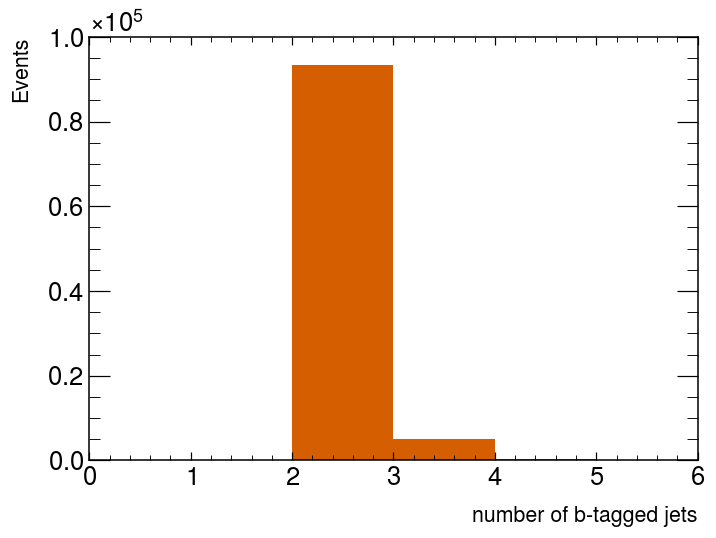

In [4]:
BINS     = range(0, 7)   # ✏️ try range(0, 5)
WEIGHTED = False         # ✏️ stretch: True to use event weights

nb = ak.num(b_jets)
print(f'exactly 2 b-tags: {int(ak.sum(nb == 2))}     more than 2: {int(ak.sum(nb > 2))}')

w = ak.to_numpy(weights.weight_for('ttbar', events)) if WEIGHTED else None
plt.hist(ak.to_numpy(nb), bins=BINS, weights=w)
plt.xlabel('number of b-tagged jets'); plt.ylabel('Events')